## Isolation Forest

In [15]:
# Configuration
CONFIG = {
    'dataset_path': 'data/train_test_network.csv',
    'pipeline_file': 'pipeline/shared_preprocessing_20260116_185312.pkl',
    'model_file': 'model/ocsvm_model_20260117_124040.pkl',
    'enable_monitoring': True,
    'random_state': 42
}

print("Configuration:")
for key, value in CONFIG.items():
    print(f"  {key}: {value}")

print("\n  Important: random_state must match training notebook to ensure same test set!")

Configuration:
  dataset_path: data/train_test_network.csv
  pipeline_file: pipeline/shared_preprocessing_20260116_185312.pkl
  model_file: model/ocsvm_model_20260117_124040.pkl
  enable_monitoring: True
  random_state: 42

  Important: random_state must match training notebook to ensure same test set!


In [28]:
from ton_iot_pipeline import load_and_split_data

#df = pd.read_csv(CONFIG['dataset_path'])
# df_train, df_test = train_test_split(df, test_size=0.2, random_state=CONFIG['random_state'])
# X_test_raw = df_test.drop(columns=["label", "type"])

X_train, X_val, X_test, y_train, y_val, y_test, _, _, _ = load_and_split_data(
    filepath=CONFIG['dataset_path'],
    random_state=CONFIG['random_state']
)

Loading dataset...
Dataset shape: (211043, 44)
Features: ['src_ip', 'src_port', 'dst_ip', 'dst_port', 'proto', 'service', 'duration', 'src_bytes', 'dst_bytes', 'conn_state', 'missed_bytes', 'src_pkts', 'src_ip_bytes', 'dst_pkts', 'dst_ip_bytes', 'dns_query', 'dns_qclass', 'dns_qtype', 'dns_rcode', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_request_body_len', 'http_response_body_len', 'http_status_code', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice', 'label', 'type']

Data split (stratified by attack type):
  Train: 147,730 samples (70.0%)
  Val:   31,656 samples (15.0%)
  Test:  31,657 samples (15.0%)

Label distribution (0=normal, 1=attack):
  Train: 76.31% attacks
  Val:   76.31% attacks
  Test:  76.31% attacks


In [17]:
from preprocessing import IsoForestPreprocessor

preprocessor = IsoForestPreprocessor()
X_train_isotree = preprocessor.preprocess(X_train)
# taking only normal data for training
X_train_isotree = X_train_isotree[y_train == 0]
#X_train = df_train[df_train['label'] == 0].drop(columns=['label', 'type'])
X_val_isotree = preprocessor.preprocess(X_val, train=False)
X_test_isotree = preprocessor.preprocess(X_test, train=False)
#X_test = df_test.drop(columns=['label', 'type'])
#Y_test = df_test['label']

In [18]:
import pandas as pd

# 1. Masken erstellen basierend auf y_val
mask_normal = (y_val == 0)
mask_anomaly = (y_val == 1)

# 2. Daten aufteilen
X_normal = X_val_isotree[mask_normal]
y_normal = y_val[mask_normal]

X_anomaly = X_val_isotree[mask_anomaly]
y_anomaly = y_val[mask_anomaly]

# 3. Downsampling der Anomalien (1%)
# Wir nehmen ein Sample vom Index und wenden es auf beide an
anomaly_sample_indices = X_anomaly.sample(frac=0.01, random_state=42).index

X_anomaly_sample = X_anomaly.loc[anomaly_sample_indices]
y_anomaly_sample = y_anomaly.loc[anomaly_sample_indices]

# 4. Zusammenführen
X_val_reduced = pd.concat([X_normal, X_anomaly_sample])
y_val_reduced = pd.concat([y_normal, y_anomaly_sample])

In [ ]:
# reducing test set so that it contains 1% anomalies
# normal_df = df_test[df_test['label'] == 0]
# anomaly_df = df_test[df_test['label'] == 1]
# anomaly_sample = anomaly_df.sample(frac=0.01, random_state=42)
# df_test = pd.concat([normal_df, anomaly_sample])
# X_test = df_test.drop(columns=['label', 'type'])   
# Y_test = df_test['label']

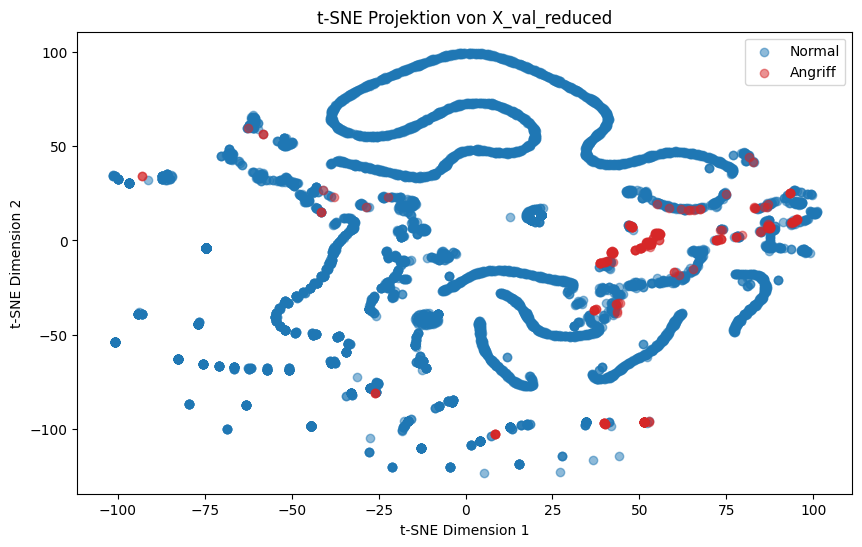

In [19]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import numpy as np
# tsne only for numerical features
X_val_numeric = X_val_reduced.select_dtypes(include=[np.number])

tsne = TSNE(n_components=2, random_state=42)
X_val_2d = tsne.fit_transform(X_val_numeric)
plt.figure(figsize=(10, 6))
plt.scatter(
    X_val_2d[y_val_reduced == 0, 0], X_val_2d[y_val_reduced == 0, 1],
    c='#1f77b4', label='Normal', alpha=0.5
)
plt.scatter(
    X_val_2d[y_val_reduced == 1, 0], X_val_2d[y_val_reduced == 1, 1],
    c='#d62728', label='Angriff', alpha=0.5
)
plt.legend()
plt.title('t-SNE Projektion von X_val_reduced')
plt.xlabel('t-SNE Dimension 1')
plt.ylabel('t-SNE Dimension 2')
plt.show()

In [20]:
# 3 dimensional t-SNE plot (using plotly for interactivity)
import plotly.express as px
tsne_3d = TSNE(n_components=3, random_state=42)
X_val_3d = tsne_3d.fit_transform(X_val_numeric)
fig = px.scatter_3d(
    x=X_val_3d[:, 0],
    y=X_val_3d[:, 1],
    z=X_val_3d[:, 2],
    color=y_val_reduced.map({0: 'Normal', 1: 'Angriff'}),
    title='3D t-SNE Projektion von X_val_reduced',
    labels={'x': 't-SNE Dimension 1', 'y': 't-SNE Dimension 2', 'z': 't-SNE Dimension 3'}
)
fig.show()

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.



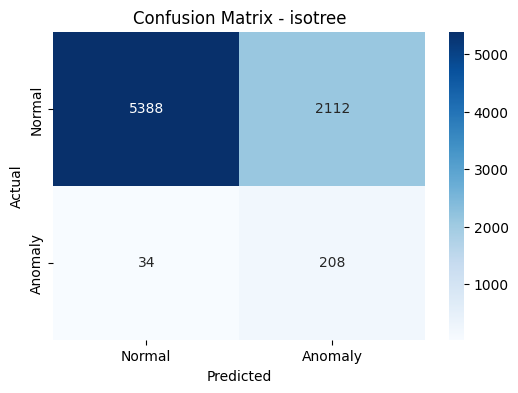

Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.72      0.83      7500
     Angriff       0.09      0.86      0.16       242

    accuracy                           0.72      7742
   macro avg       0.54      0.79      0.50      7742
weighted avg       0.97      0.72      0.81      7742



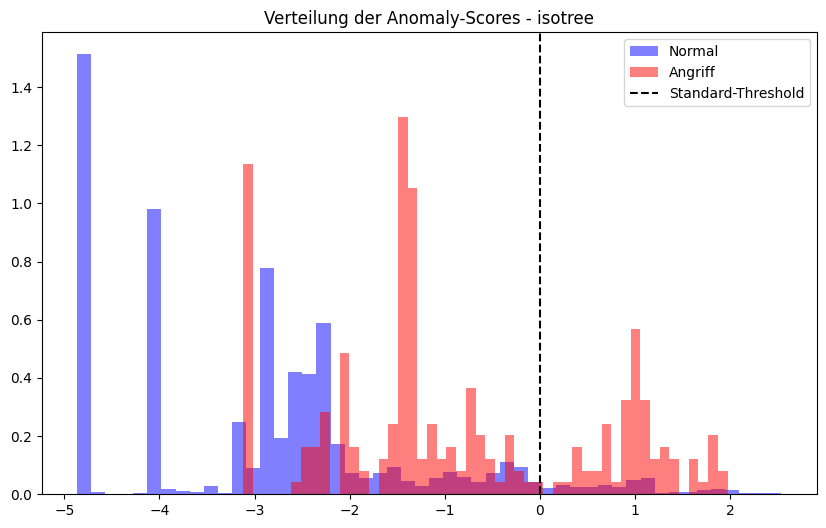

In [21]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
from ton_iot_utils import plot_score_distribution, plot_confusion_matrix
# David Setup (High-Performance Variante)
iforest = isotree.IsolationForest(
    ndim=1,
    ntrees=200,
    sample_size=256,
    missing_action="fail",
    max_depth=8,
    categ_split_type="single_categ",
    scoring_metric="density",
    random_state=42,
)

iforest.fit(X_train_isotree)
scores = iforest.predict(X_val_reduced)

threshold = np.percentile(scores, 70) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_reduced, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = iforest.decision_function(X_val_reduced)
report = classification_report(y_val_reduced, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(iforest, X_val_reduced, y_val_reduced, "isotree")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.



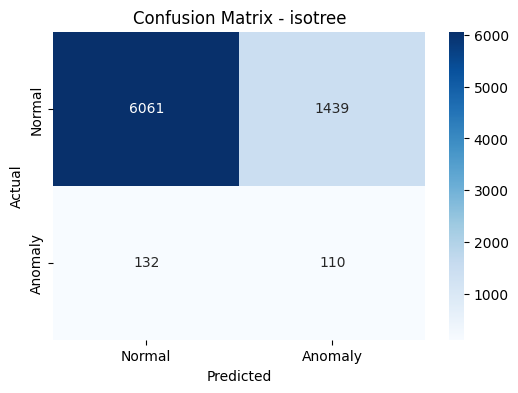

Classification Report:
               precision    recall  f1-score   support

      Normal       0.98      0.81      0.89      7500
     Angriff       0.07      0.45      0.12       242

    accuracy                           0.80      7742
   macro avg       0.52      0.63      0.50      7742
weighted avg       0.95      0.80      0.86      7742



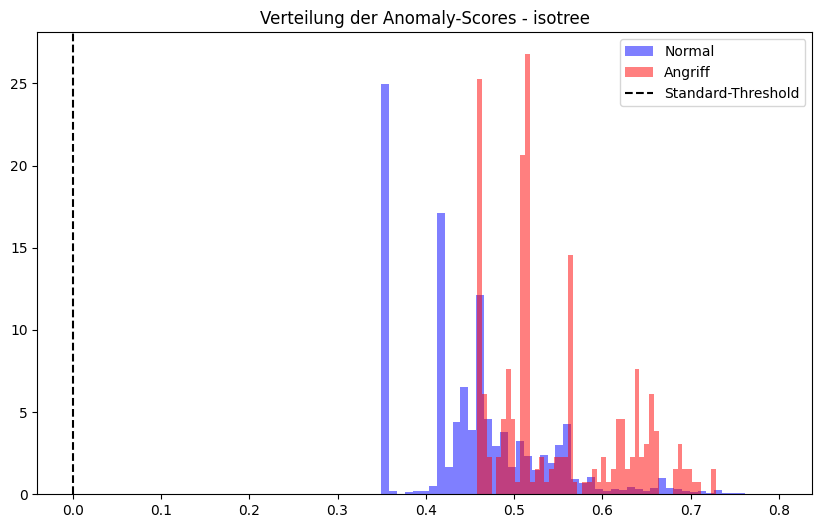

In [22]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix
# David Setup (High-Performance Variante)
eif = isotree.IsolationForest(
    ndim=2,
    ntrees=100,
    sample_size=256,
    missing_action="fail",
    max_depth=8,
    coefs="uniform",
    standardize_data=False,
    categ_split_type="single_categ",
    random_state=42,
)

eif.fit(X_train_isotree)
scores = eif.predict(X_val_reduced)

threshold = np.percentile(scores, 80) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_reduced, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = eif.decision_function(X_val_reduced)
report = classification_report(y_val_reduced, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(eif, X_val_reduced, y_val_reduced, "isotree")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.



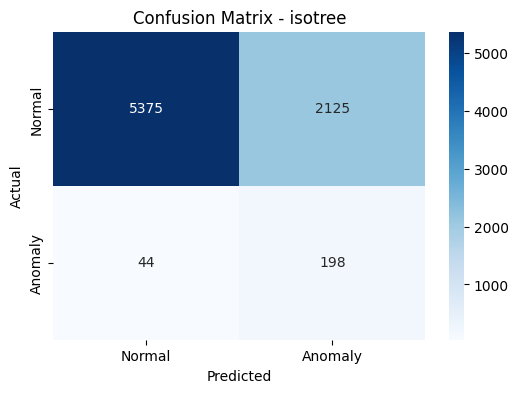

Classification Report:
               precision    recall  f1-score   support

      Normal       0.99      0.72      0.83      7500
     Angriff       0.09      0.82      0.15       242

    accuracy                           0.72      7742
   macro avg       0.54      0.77      0.49      7742
weighted avg       0.96      0.72      0.81      7742



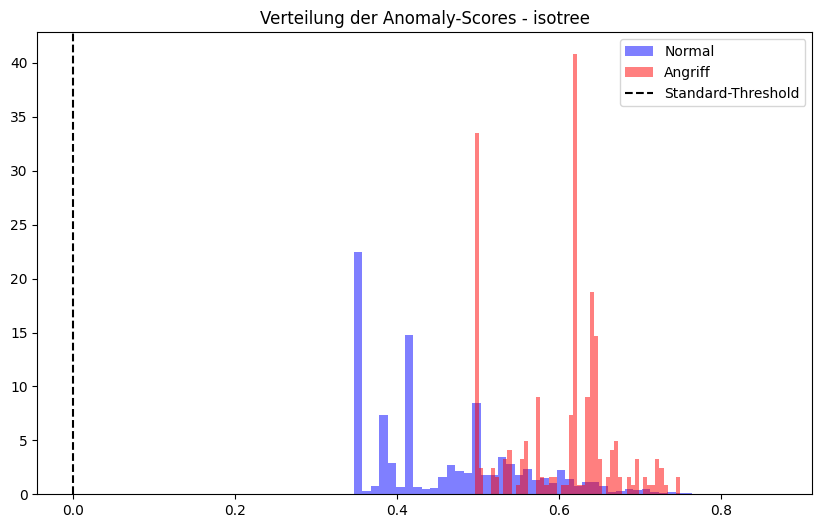

In [23]:
import isotree
import numpy as np
from sklearn.metrics import confusion_matrix
# David Setup (High-Performance Variante)
sciforest = isotree.IsolationForest(
    ndim=2,
    ntrees=100,
    sample_size=256,
    missing_action="fail",
    max_depth=8,
    coefs="normal",
    ntry=10,
    prob_pick_avg_gain=1,
    penalize_range=True,
    categ_split_type="single_categ",
    random_state=42,
)

sciforest.fit(X_train_isotree)
scores = sciforest.predict(X_val_reduced)

threshold = np.percentile(scores, 70) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_reduced, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = sciforest.decision_function(X_val_reduced)
report = classification_report(y_val_reduced, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(sciforest, X_val_reduced, y_val_reduced, "isotree")

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1737: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.

c:\Users\rapha\Documents\projects\mal-ids-project\.venv\Lib\site-packages\isotree\__init__.py:1757: UserWarning:

Instantiating CategoricalDtype without any arguments.Pass a CategoricalDtype instance to silence this warning.



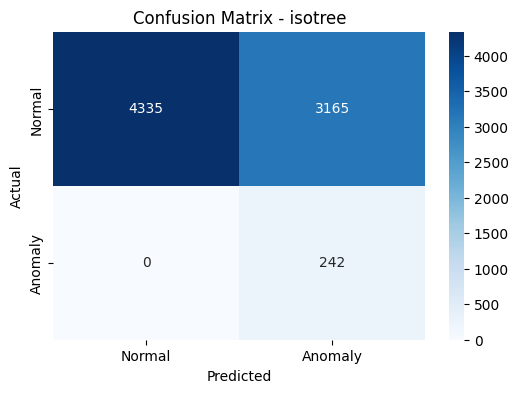

Classification Report:
               precision    recall  f1-score   support

      Normal       1.00      0.58      0.73      7500
     Angriff       0.07      1.00      0.13       242

    accuracy                           0.59      7742
   macro avg       0.54      0.79      0.43      7742
weighted avg       0.97      0.59      0.71      7742



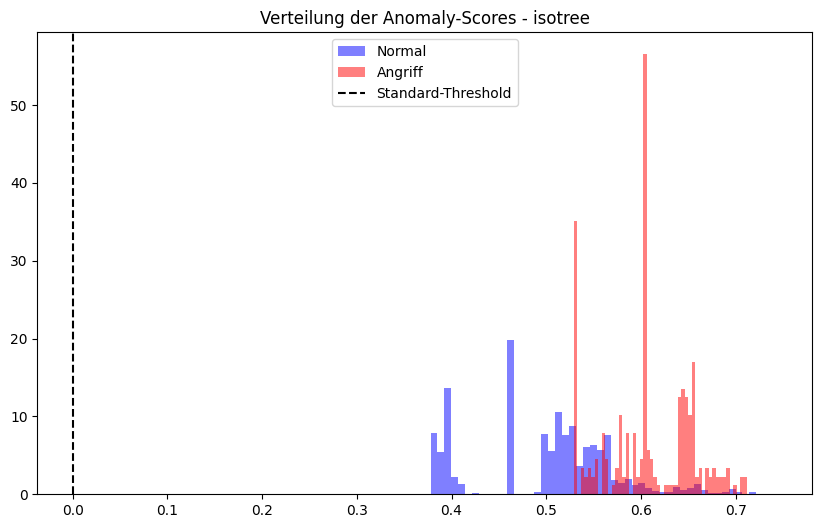

In [24]:
fcf = isotree.IsolationForest(
    ndim=2,                       # Extended (Schräge Schnitte helfen bei Clustern)
    sample_size=256,              # Bleib bei 256! (Wichtig gegen Overfitting)
    ntrees=100,
    
    # Die FCF Parameter
    prob_pick_pooled_gain=.9,
    penalize_range=False,    # Suche aktiv nach Clustern
    ntry=3,
    categ_split_type="single_categ",                       # Probiere 3 Schnitte pro Knoten, nimm den besten
    missing_action="fail",
    random_state=42
)

fcf.fit(X_train_isotree)
scores = fcf.predict(X_val_reduced)

threshold = np.percentile(scores, 56) 
Y_pred = (scores > threshold).astype(int)

cm = confusion_matrix(y_val_reduced, Y_pred)
plot_confusion_matrix(cm, "isotree")

scores = fcf.decision_function(X_val_reduced)
report = classification_report(y_val_reduced, Y_pred, target_names=['Normal', 'Angriff'])
print("Classification Report:\n", report)
plot_score_distribution(fcf, X_val_reduced, y_val_reduced, "isotree")

### save models to pickle files

In [25]:
import pickle
models = ["iforest", "eif", "sciforest", "fcf"]
for model_name in models:
    model = locals()[model_name]
    with open(f"{model_name}_model.pkl", "wb") as f:
        pickle.dump(model, f)


## CatBoost

In [29]:
from preprocessing import CatBoostPreprocessor

preprocessor = CatBoostPreprocessor()
X_train_cat = preprocessor.preprocess(X_train)
X_val_cat = preprocessor.preprocess(X_val, train=False)

In [30]:
from catboost import CatBoostClassifier, Pool

train_pool = Pool(data=X_train_cat, label=y_train,
                  cat_features=preprocessor.categorical_cols)
test_pool = Pool(data=X_val_cat, label=y_val,
                 cat_features=preprocessor.categorical_cols)

model = CatBoostClassifier(iterations=2,
                           depth=2,
                           learning_rate=1,
                           loss_function='Logloss',
                           verbose=True)
# train the model
model.fit(train_pool)
# make the prediction using the resulting model
preds_class = model.predict(test_pool)
preds_proba = model.predict_proba(test_pool)
performance = classification_report(y_val, preds_class)
print(performance)
cm = confusion_matrix(y_val, preds_class)
plot_confusion_matrix(cm, "catboost")

CatBoostError: Invalid type for cat_feature[non-default value idx=0,feature_idx=10]=0.0 : cat_features must be integer or string, real number values and NaN values should be converted to string.

[I 2026-01-17 13:04:03,707] A new study created in memory with name: no-name-d22c741b-6338-4651-99e8-df663b7e7c4e
[I 2026-01-17 13:04:10,907] Trial 0 finished with value: 0.9770901940344476 and parameters: {'iterations': 218, 'depth': 1, 'learning_rate': 0.03042457457480203}. Best is trial 0 with value: 0.9770901940344476.
[I 2026-01-17 13:04:56,902] Trial 1 finished with value: 0.9841029164396219 and parameters: {'iterations': 378, 'depth': 4, 'learning_rate': 0.0011582624703825129}. Best is trial 1 with value: 0.9841029164396219.
[I 2026-01-17 13:10:38,969] Trial 2 finished with value: 0.9981757445094648 and parameters: {'iterations': 816, 'depth': 10, 'learning_rate': 0.037400869843141726}. Best is trial 2 with value: 0.9981757445094648.


0:	learn: 0.5809760	total: 408ms	remaining: 5m 32s
1:	learn: 0.5033386	total: 865ms	remaining: 5m 52s
2:	learn: 0.4368758	total: 1.29s	remaining: 5m 49s
3:	learn: 0.3845125	total: 1.71s	remaining: 5m 46s
4:	learn: 0.3345785	total: 2.16s	remaining: 5m 50s
5:	learn: 0.2854289	total: 2.55s	remaining: 5m 44s
6:	learn: 0.2454410	total: 2.96s	remaining: 5m 41s
7:	learn: 0.2146040	total: 3.39s	remaining: 5m 42s
8:	learn: 0.1958657	total: 3.81s	remaining: 5m 41s
9:	learn: 0.1688834	total: 4.2s	remaining: 5m 38s
10:	learn: 0.1471046	total: 4.6s	remaining: 5m 36s
11:	learn: 0.1353996	total: 5s	remaining: 5m 35s
12:	learn: 0.1260344	total: 5.42s	remaining: 5m 34s
13:	learn: 0.1178175	total: 5.82s	remaining: 5m 33s
14:	learn: 0.1080017	total: 6.22s	remaining: 5m 32s
15:	learn: 0.0953495	total: 6.64s	remaining: 5m 31s
16:	learn: 0.0853459	total: 7.04s	remaining: 5m 31s
17:	learn: 0.0801308	total: 7.45s	remaining: 5m 30s
18:	learn: 0.0753565	total: 7.87s	remaining: 5m 30s
19:	learn: 0.0713501	total:

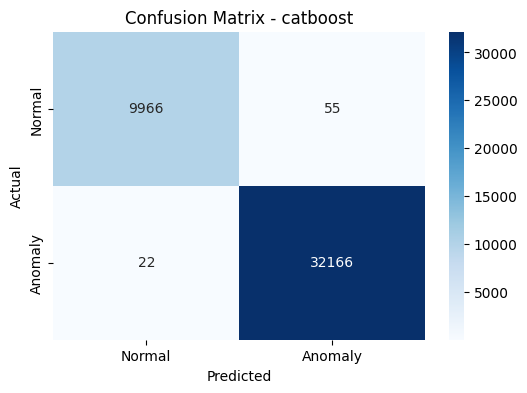

In [13]:
from catboost import CatBoostClassifier, Pool
from ton_iot_utils import plot_confusion_matrix
from sklearn.metrics import confusion_matrix, classification_report
import optuna

train_pool = Pool(data=X_train, label=y_train,
                  cat_features=preprocessor.categorical_cols)
test_pool = Pool(data=X_test, label=y_test,
                 cat_features=preprocessor.categorical_cols)

# hyperparameter tuning using optuna
def objective(trial):
    param = {
        "iterations": trial.suggest_int("iterations", 100, 1000),
        "depth": trial.suggest_int("depth", 1, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 1e-1, log=True),
        "loss_function": "Logloss",
        "verbose": False
    }
    model = CatBoostClassifier(**param)
    model.fit(train_pool)
    preds = model.predict(test_pool)
    accuracy = (preds == y_test).mean()
    return accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=3)

best_params = study.best_params
model = CatBoostClassifier(**best_params,
                           verbose=True)
# train the model
model.fit(train_pool)
# make the prediction using the resulting model
preds_class = model.predict(test_pool)
preds_proba = model.predict_proba(test_pool)
performance = classification_report(y_test, preds_class)
print(performance)
cm = confusion_matrix(y_test, preds_class)
plot_confusion_matrix(cm, "catboost")

[I 2026-01-17 13:50:08,407] A new study created in memory with name: no-name-2d0e3504-0d71-4447-b4ce-813b82cf0afc


Training on fold [0/3]

bestTest = 0.9966239628
bestIteration = 392

Training on fold [1/3]

bestTest = 0.9974057358
bestIteration = 563

Training on fold [2/3]


[I 2026-01-17 13:52:56,196] Trial 0 finished with value: 0.9969378215276737 and parameters: {'learning_rate': 0.0362959250242443, 'depth': 4, 'l2_leaf_reg': 2}. Best is trial 0 with value: 0.9969378215276737.



bestTest = 0.9968015353
bestIteration = 335

Training on fold [0/3]

bestTest = 0.9958776808
bestIteration = 479

Training on fold [1/3]

bestTest = 0.9964284445
bestIteration = 598

Training on fold [2/3]


[I 2026-01-17 13:57:35,180] Trial 1 finished with value: 0.996298143419935 and parameters: {'learning_rate': 0.009274499305529883, 'depth': 6, 'l2_leaf_reg': 9}. Best is trial 0 with value: 0.9969378215276737.


...


bestTest = 0.9893029124
bestIteration = 2

Training on fold [0/3]

bestTest = 0.9978144601
bestIteration = 251

Training on fold [1/3]

bestTest = 0.9981875689
bestIteration = 264

Training on fold [2/3]


[I 2026-01-17 14:03:41,976] Trial 3 finished with value: 0.9979861884577533 and parameters: {'learning_rate': 0.0710311165889898, 'depth': 10, 'l2_leaf_reg': 2}. Best is trial 3 with value: 0.9979861884577533.



bestTest = 0.9979743057
bestIteration = 199

Training on fold [0/3]

bestTest = 0.9958954495
bestIteration = 615

Training on fold [1/3]

bestTest = 0.9850207897
bestIteration = 18

Training on fold [2/3]


[I 2026-01-17 14:05:35,404] Trial 4 finished with value: 0.9887344337728939 and parameters: {'learning_rate': 0.011953929113471899, 'depth': 4, 'l2_leaf_reg': 3}. Best is trial 3 with value: 0.9979861884577533.



bestTest = 0.9853226007
bestIteration = 15

Beste Parameter: {'learning_rate': 0.0710311165889898, 'depth': 10, 'l2_leaf_reg': 2}
0:	learn: 0.4928104	total: 542ms	remaining: 9m 1s
1:	learn: 0.3681364	total: 1.1s	remaining: 9m 11s
2:	learn: 0.2683972	total: 1.71s	remaining: 9m 26s
3:	learn: 0.2046617	total: 2.25s	remaining: 9m 20s
4:	learn: 0.1606763	total: 2.77s	remaining: 9m 10s
5:	learn: 0.1384276	total: 3.3s	remaining: 9m 7s
6:	learn: 0.1195671	total: 3.84s	remaining: 9m 4s
7:	learn: 0.1042685	total: 4.34s	remaining: 8m 58s
8:	learn: 0.0860046	total: 4.88s	remaining: 8m 56s
9:	learn: 0.0767518	total: 5.43s	remaining: 8m 57s
10:	learn: 0.0701889	total: 5.96s	remaining: 8m 55s
11:	learn: 0.0647319	total: 6.49s	remaining: 8m 54s
12:	learn: 0.0595391	total: 7.05s	remaining: 8m 55s
13:	learn: 0.0504714	total: 7.59s	remaining: 8m 54s
14:	learn: 0.0460477	total: 8.17s	remaining: 8m 56s
15:	learn: 0.0425265	total: 8.75s	remaining: 8m 58s
16:	learn: 0.0369445	total: 9.24s	remaining: 8m 54s


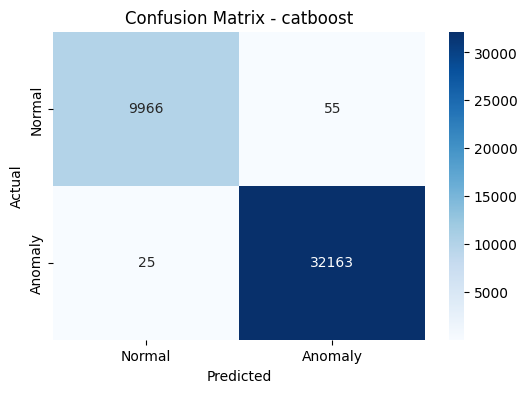

In [ ]:
from catboost import CatBoostClassifier, Pool, cv
from sklearn.metrics import classification_report, confusion_matrix
import optuna

# Wir nutzen hier NUR train_pool für die Optimierung!
# test_pool fassen wir erst GANZ am Ende an.
train_pool = Pool(data=X_train, label=y_train, 
                  cat_features=preprocessor.categorical_cols)

def objective(trial):
    params = {
        "iterations": 1000, # Fest hoch setzen, Early Stopping regelt das
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "depth": trial.suggest_int("depth", 4, 10),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 1, 9),
        "loss_function": "Logloss",
        "eval_metric": "Accuracy", # oder "AUC" / "F1"
        "early_stopping_rounds": 50,
        "verbose": False
    }

    # Interne CatBoost Cross-Validation
    # Dies teilt X_train intern in z.B. 3 Folds
    cv_data = cv(
        params=params,
        pool=train_pool,
        fold_count=3, # 3-fache Cross Validation
        shuffle=True,
        partition_random_seed=42,
        plot=False,
        verbose=False
    )
    
    # cv gibt einen DataFrame zurück. Wir holen den besten Test-Score.
    # Wichtig: Das ist der Score auf dem Validierungs-Teil von X_train, NICHT X_test!
    best_accuracy = cv_data['test-Accuracy-mean'].max()
    
    return best_accuracy

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5) # 20-50 Trials reichen oft

print("Beste Parameter:", study.best_params)

# --- Finales Training ---
# Jetzt trainieren wir auf dem GANZEN X_train mit den besten Parametern
final_params = study.best_params
final_params['iterations'] = 1000 # Muss manuell wieder gesetzt werden
final_params['verbose'] = True

# model = CatBoostClassifier(**final_params)
model = CatBoostClassifier(
    iterations=final_params['iterations'],
    learning_rate=final_params['learning_rate'],
    depth=final_params['depth'],
    l2_leaf_reg=final_params['l2_leaf_reg'],
    loss_function="Logloss",
    eval_metric="Accuracy",
    verbose=True
)
model.fit(train_pool) # Training auf X_train

# --- Finale Evaluation ---
# ERST JETZT darf das Testset berührt werden
test_pool = Pool(data=X_test, label=y_test, 
                 cat_features=preprocessor.categorical_cols)

preds_class = model.predict(test_pool)
print(classification_report(y_test, preds_class))
cm = confusion_matrix(y_test, preds_class)
plot_confusion_matrix(cm, "catboost")

In [15]:
# saving model as pickle
import pickle
with open('catboost_model.pkl', 'wb') as f:
    pickle.dump(model, f)